In [11]:
import scipy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

## Exercice 1

In [12]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

print(f"Scipy version: {scipy.__version__}")
print(f"Numpy version: {np.__version__}")

sub_modules = [
    ("Scipy.stats", "Statistical tests, probability distributions"),
    ("scipy.optimize", "Optimization and root search"),
    ("scipy.interpolate", "Interpolation and approximation"),
    ("scipy.linalg", "Advanced Linear Algebra"),
    ("scipy.spatial", "Spatial structures and geometric algorithms"),
    ("scipy.signal", "Signal processing"),
    ("scipy.ndimage", "N-dimensional image processing"),
    ("scipy.integrate", "Numerical Integration"),
]

print("Scipy Sub-modules:")
for name, description in sub_modules:
    print(f"- {name}: {description}")

Scipy version: 1.17.1
Numpy version: 2.4.6
Scipy Sub-modules:
- Scipy.stats: Statistical tests, probability distributions
- scipy.optimize: Optimization and root search
- scipy.interpolate: Interpolation and approximation
- scipy.linalg: Advanced Linear Algebra
- scipy.spatial: Spatial structures and geometric algorithms
- scipy.signal: Signal processing
- scipy.ndimage: N-dimensional image processing
- scipy.integrate: Numerical Integration


## Exercice 2

Mean: 16.625
Median: 16.5
Variance: 17.125
Standard Deviation: 4.138236339311712
Size: 8
Min: 12
Max: 22
Skewness: 0.06525681329773589
Kurtosis: -1.6476734867850917


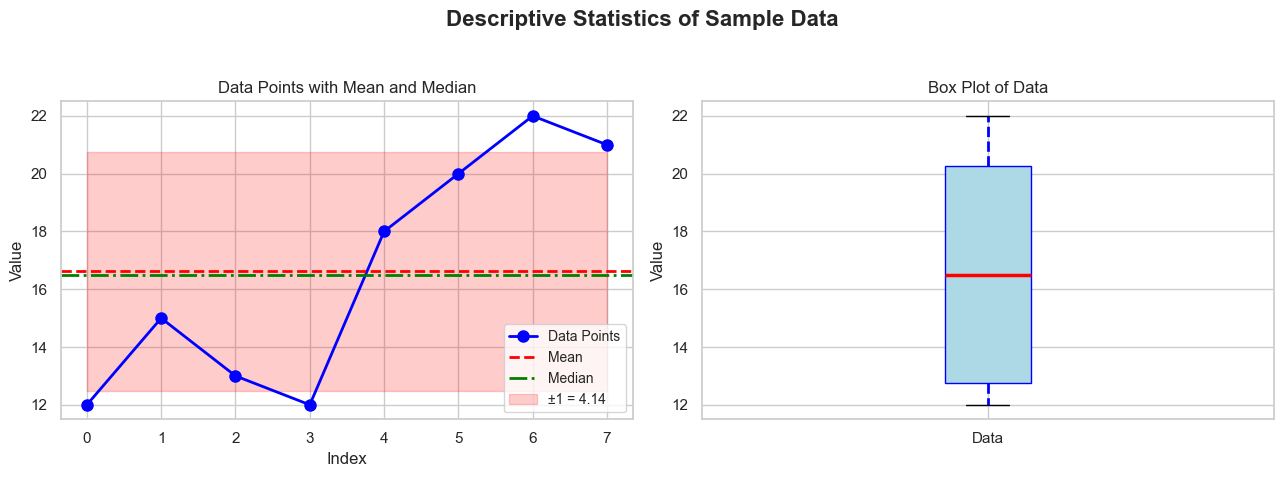

In [13]:
data = [12, 15, 13, 12, 18, 20, 22, 21]

mean = np.mean(data)
median = np.median(data)
variance = np.var(data, ddof=1)
std_dev = np.std(data, ddof=1)

descriptive_stats = stats.describe(data)

print(f"Mean: {mean}")
print(f"Median: {median}")
print(f"Variance: {variance}")
print(f"Standard Deviation: {std_dev}")
print(f"Size: {descriptive_stats.nobs}")
print(f"Min: {descriptive_stats.minmax[0]}")
print(f"Max: {descriptive_stats.minmax[1]}")
print(f"Skewness: {descriptive_stats.skewness}")
print(f"Kurtosis: {descriptive_stats.kurtosis}")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Descriptive Statistics of Sample Data', fontsize=16, fontweight='bold')

axes[0].plot(data, marker='o', linestyle='-', linewidth=2, markersize=8, color='blue', label='Data Points')
axes[0].axhline(mean, color='red', linestyle='--', linewidth=2, label='Mean')
axes[0].axhline(median, color='green', linestyle='-.', linewidth=2, label='Median')
axes[0].fill_between(range(len(data)), 
                     mean - std_dev, mean + std_dev, 
                     color='red', alpha=0.2, label=f'±1 = {std_dev:.2f}')
axes[0].set_title('Data Points with Mean and Median', fontsize=12)
axes[0].set_xlabel('Index')
axes[0].set_ylabel('Value')
axes[0].legend(fontsize=10)

#Graphic 2
axes[1].boxplot(data, vert=True, patch_artist=True, boxprops=dict(facecolor='lightblue', color='blue'),
                medianprops=dict(color='red', linewidth=2.5), 
                whiskerprops=dict(color='blue', linewidth=2, linestyle='--'))
axes[1].set_title('Box Plot of Data', fontsize=12)
axes[1].set_ylabel('Value')
axes[1].set_xticks([1])
axes[1].set_xticklabels(['Data'])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Exercice 3

Probability within ±1σ: 0.6827 (68.27%)
Probability within ±2σ: 0.9545 (95.45%)
Probability within ±3σ: 0.9973 (99.73%)
Total probability within ±3σ: 0.9973 (99.73%)


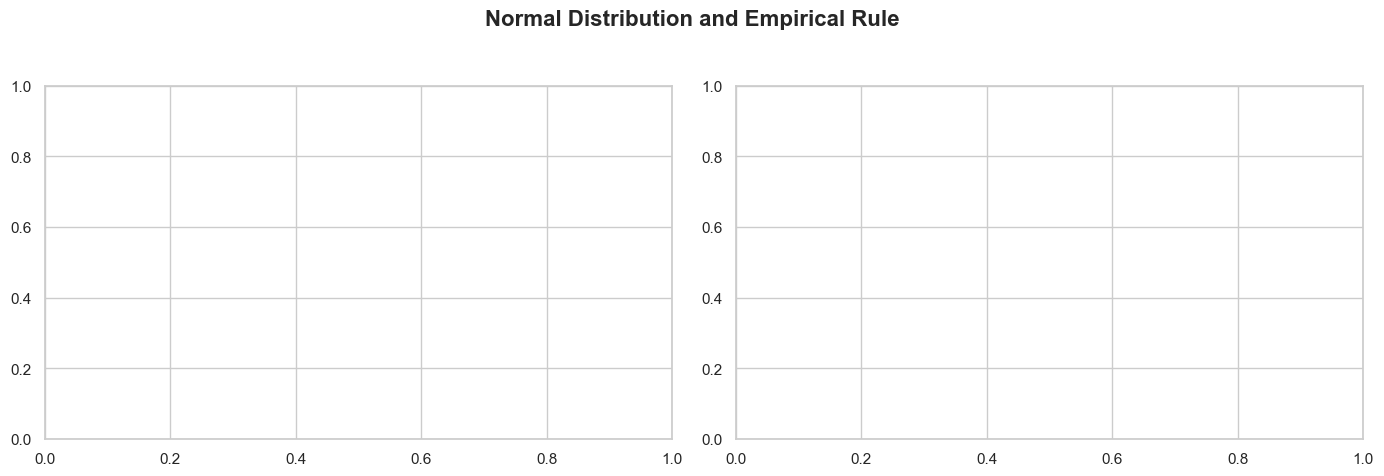

In [14]:
from scipy import stats

mu = 50
sigma = 10

x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
pdf = stats.norm.pdf(x, mu, sigma)
cdf = stats.norm.cdf(x, mu, sigma)

p_1sigma = stats.norm.cdf(mu + sigma, mu, sigma) - stats.norm.cdf(mu - sigma, mu, sigma)
p_2sigma = stats.norm.cdf(mu + 2*sigma, mu, sigma) - stats.norm.cdf(mu - 2*sigma, mu, sigma)
p_3sigma = stats.norm.cdf(mu + 3*sigma, mu, sigma) - stats.norm.cdf(mu - 3*sigma, mu, sigma)

print(f"Probability within ±1σ: {p_1sigma:.4f} ({p_1sigma*100:.2f}%)")
print(f"Probability within ±2σ: {p_2sigma:.4f} ({p_2sigma*100:.2f}%)")
print(f"Probability within ±3σ: {p_3sigma:.4f} ({p_3sigma*100:.2f}%)")
print(f"Total probability within ±3σ: {p_3sigma:.4f} ({p_3sigma*100:.2f}%)")

# Visualisation
fig, ax = plt.subplots(1, 2,figsize=(14, 5))
fig.suptitle('Normal Distribution and Empirical Rule', fontsize=16, fontweight='bold')

# Graphic 1: PDF and CDF
ax = axes[0]
ax.plot(x, pdf, label='PDF', color='blue', linewidth=2.5)
ax.axvline(mu, color='black', linestyle='--', linewidth=1.5, label='Mean (μ)')

# Shading for ±1σ, ±2σ, ±3σ
for i, color, label in zip([1, 2, 3], ['red', 'orange', 'green'], ['±1σ', '±2σ', '±3σ']):
    ax.fill_between(x, 0, pdf, where=((x >= mu - i*sigma) & (x <= mu + i*sigma)), color=color, alpha=0.3, label=label)

    ax.set_title('Normal Distribution (PDF)', fontsize=12)
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    ax.legend(fontsize=10)

# Graphic 2: CDF
ax = axes[1]
ax.plot(x, cdf, label='CDF', color='green', linewidth=2.5)
ax.axvline(mu, color='black', linestyle='--', linewidth=1.5, label='Mean (50%)')
ax.axvline(mu - sigma, color='red', linestyle='--', linewidth=1.5, label='2.5%')
ax.axvline(mu + sigma, color='red', linestyle='--', linewidth=1.5, label='97.5%')
ax.set_title('Cumulative Distribution Function (CDF)', fontsize=12)
ax.set_xlabel('Value')
ax.set_ylabel('Cumulative Probability')
ax.legend(fontsize=10)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Exercice 4

T-statistic: -19.2220, P-value: 0.0000
Significance level (alpha): 0.05
t-Statistic: -19.2220
p-Value: 0.0000
Significance level (alpha): 0.05
t-Statistic: -19.2220
p-Value: 0.0000
Significance level (alpha): 0.05
Reject the null hypothesis (p-value: 0.0000) - Significant difference between groups


C:\Users\meles\AppData\Local\Temp\ipykernel_2808\2472644305.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([data1, data2], labels=['Group 1', 'Group 2'], patch_artist=True, boxprops=dict(facecolor='lightblue', color='blue'),


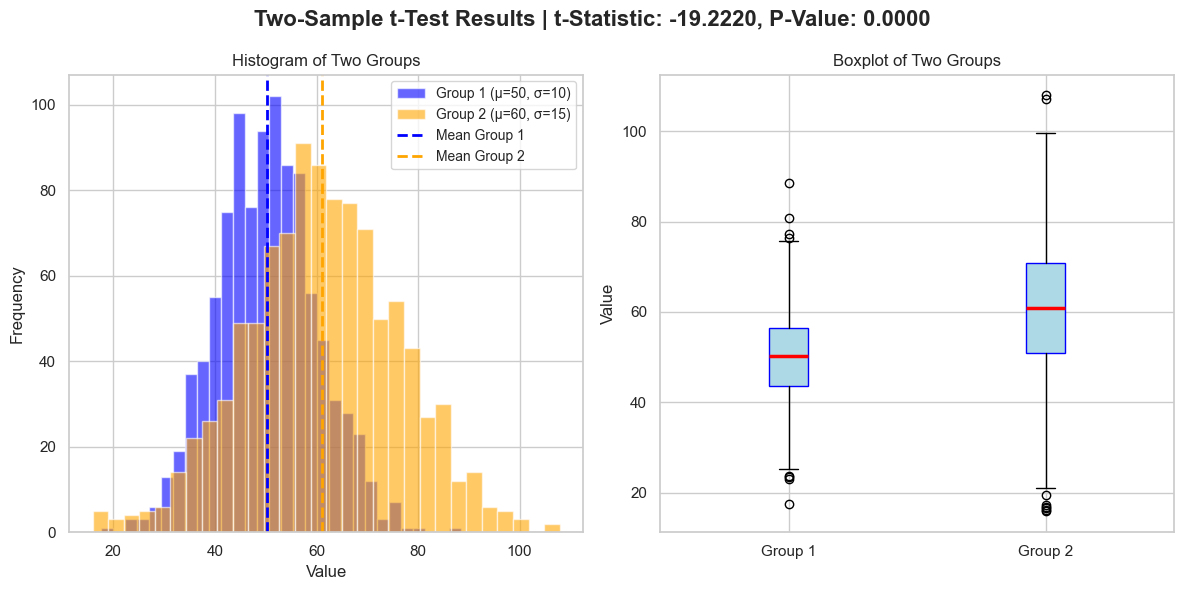

In [15]:
np.random.seed(42)
data1 = np.random.normal(loc=50, scale=10, size=1000)
data2 = np.random.normal(loc=60, scale=15, size=1000)

t_statistic, p_value = stats.ttest_ind(data1, data2)

alpha = 0.05
print(f"T-statistic: {t_statistic:.4f}, P-value: {p_value:.4f}")
print(f"Significance level (alpha): {alpha}")
print(f"t-Statistic: {t_statistic:.4f}")
print(f"p-Value: {p_value:.4f}")
print(f"Significance level (alpha): {alpha}")
print(f"t-Statistic: {t_statistic:.4f}")
print(f"p-Value: {p_value:.4f}")
print(f"Significance level (alpha): {alpha}")
if p_value < alpha:
    print(f"Reject the null hypothesis (p-value: {p_value:.4f}) - Significant difference between groups")
else:
    print(f"Fail to reject the null hypothesis (p-value: {p_value:.4f}) - No significant difference between groups")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle('Two-Sample t-Test Results | t-Statistic: {:.4f}, P-Value: {:.4f}'.format(t_statistic, p_value), 
             fontsize=16, fontweight='bold')

# Histogram of both groups
ax = axes[0]
ax.hist(data1, bins=30, alpha=0.6, color='blue', label='Group 1 (μ=50, σ=10)')
ax.hist(data2, bins=30, alpha=0.6, color='orange', label='Group 2 (μ=60, σ=15)')
ax.axvline(np.mean(data1), color='blue', linestyle='--', linewidth=2, label='Mean Group 1')
ax.axvline(np.mean(data2), color='orange', linestyle='--', linewidth=2, label='Mean Group 2')
ax.set_title('Histogram of Two Groups', fontsize=12)
ax.set_xlabel('Value') 
ax.set_ylabel('Frequency')
ax.legend(fontsize=10)

# Boxplot of both groups
ax = axes[1]
ax.boxplot([data1, data2], labels=['Group 1', 'Group 2'], patch_artist=True, boxprops=dict(facecolor='lightblue', color='blue'),
           medianprops=dict(color='red', linewidth=2.5))
ax.set_title('Boxplot of Two Groups', fontsize=12)
ax.set_ylabel('Value')

plt.tight_layout()
plt.show()

## Exercice 5

 Linear Regression — Real Estate Prices
  Equation : Price = 1828.77 × Size + 64383.56
  Slope (β₁)          : 1828.77 €/m²
  Intercept (β₀)      : 64383.56 €
  Correlation Coefficient r       : 0.9942
  R² (variance exp.)  : 0.9884  (98.8%)
  P-Value (slope)    : 0.000531
  Standard Error     : 114.27

 Prediction :
  A house of 90 m² would cost approximately : 228,973 €

 Interpretation :
  → Each additional m² increases the price by 1829 €.
  → The model explains 98.8% of the variance in prices.
  → The slope is significant (p = 0.0005).


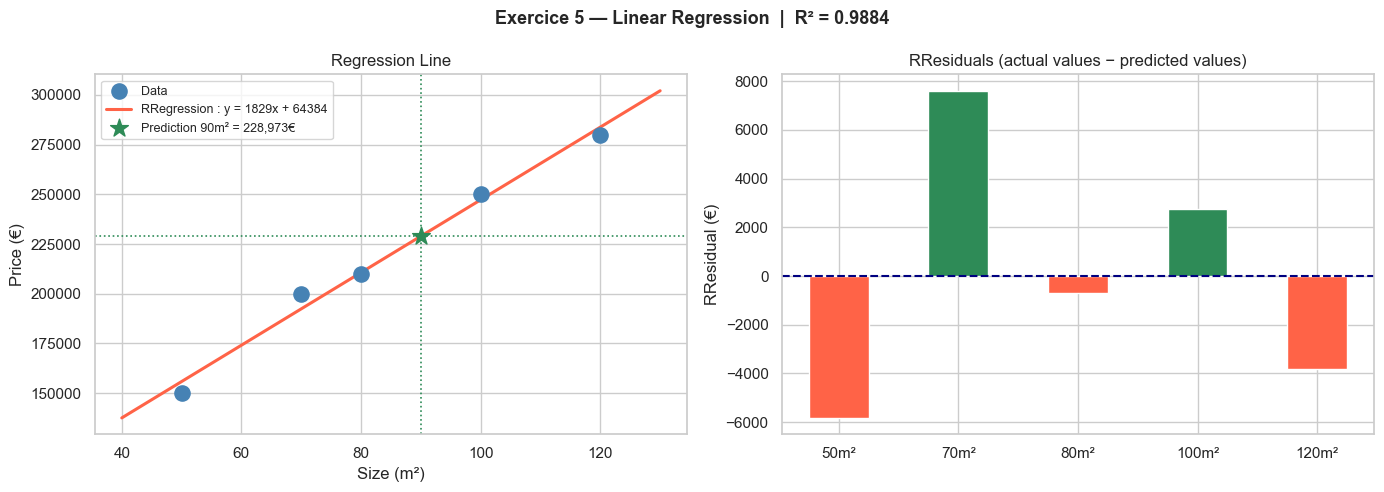

In [16]:
from scipy.stats import linregress

house_sizes  = np.array([50, 70, 80, 100, 120])           # en m²
house_prices = np.array([150000, 200000, 210000, 250000, 280000])  # en €

# Linear regression
result = linregress(house_sizes, house_prices)

slope     = result.slope        # pente (β₁)
intercept = result.intercept    # ordonnée à l'origine (β₀)
r_value   = result.rvalue       # coefficient de corrélation
r_squared = r_value**2          # R²
p_value   = result.pvalue       # significativité de la pente
std_err   = result.stderr       # erreur standard

print(" Linear Regression — Real Estate Prices")
print("=" * 50)
print(f"  Equation : Price = {slope:.2f} × Size + {intercept:.2f}")
print(f"  Slope (β₁)          : {slope:.2f} €/m²")
print(f"  Intercept (β₀)      : {intercept:.2f} €")
print(f"  Correlation Coefficient r       : {r_value:.4f}")
print(f"  R² (variance exp.)  : {r_squared:.4f}  ({r_squared*100:.1f}%)")
print(f"  P-Value (slope)    : {p_value:.6f}")
print(f"  Standard Error     : {std_err:.2f}")

# Prediction for 90 m² 
size_target = 90
price_predicted  = slope * size_target + intercept
print(f"\n Prediction :")
print(f"  A house of {size_target} m² would cost approximately : {price_predicted:,.0f} €")

# Interpretation 
print(f"\n Interpretation :")
print(f"  → Each additional m² increases the price by {slope:.0f} €.")
print(f"  → The model explains {r_squared*100:.1f}% of the variance in prices.")
print(f"  → The slope is {'significant' if p_value < 0.05 else 'not significant'} (p = {p_value:.4f}).")

# Visualization 
x_line = np.linspace(40, 130, 200)
y_line = slope * x_line + intercept

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"Exercice 5 — Linear Regression  |  R² = {r_squared:.4f}",
             fontsize=13, fontweight='bold')

# Graphic 1 : regression line
ax = axes[0]
ax.scatter(house_sizes, house_prices, color='steelblue', s=120, zorder=5, label='Data')
ax.plot(x_line, y_line, color='tomato', linewidth=2.2, label=f'RRegression : y = {slope:.0f}x + {intercept:.0f}')
ax.scatter([size_target], [price_predicted], color='seagreen', s=180, marker='*',
           zorder=6, label=f'Prediction 90m² = {price_predicted:,.0f}€')
ax.axvline(size_target, color='seagreen', linestyle=':', linewidth=1.2)
ax.axhline(price_predicted,  color='seagreen', linestyle=':', linewidth=1.2)
ax.set_xlabel('Size (m²)')
ax.set_ylabel('Price (€)')
ax.set_title('Regression Line')
ax.legend(fontsize=9)

# Graphic 2 : residuals
y_pred = slope * house_sizes + intercept
residuals = house_prices - y_pred
axes[1].bar(range(len(house_sizes)), residuals,
            color=['seagreen' if r >= 0 else 'tomato' for r in residuals],
            edgecolor='white', width=0.5)
axes[1].axhline(0, color='navy', linewidth=1.5, linestyle='--')
axes[1].set_xticks(range(len(house_sizes)))
axes[1].set_xticklabels([f'{s}m²' for s in house_sizes])
axes[1].set_title('RResiduals (actual values − predicted values)')
axes[1].set_ylabel('RResidual (€)')

plt.tight_layout()
plt.show()

## Exercice 6

ANOVA — Fertilizer efficiency
  Fertilizer 1 : mean = 5.80 cm,  data = [5, 6, 7, 6, 5]
  Fertilizer 2 : mean = 7.80 cm,  data = [7, 8, 7, 9, 8]
  Fertilizer 3 : mean = 4.00 cm,  data = [4, 5, 4, 3, 4]

  F-statistic : 28.5263
  P-Value      : 0.000028
  Significance Level α       : 0.05

 p = 0.00003 < α = 0.05
     We reject H₀: at least one fertilizer has a significantly different effect.

 Rappel des hypothèses :
  H₀ : μ₁ = μ₂ = μ₃  (tous les engrais ont le même effet)
  H₁ : Au moins une moyenne est différente

🔍 Si p > 0.05 :
  We would not be able to conclude that the fertilizers have different effects.
  The observed differences would be attributable to random variation.

 ANOVA Board :
  Source                       SC    dl         CM        F
  -------------------------------------------------------
  Inter-groupes            36.133     2     18.067  28.5263
  Intra-groupes             7.600    12      0.633
  Total                    43.733    14


C:\Users\meles\AppData\Local\Temp\ipykernel_2808\892728229.py:78: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(groups, patch_artist=True,


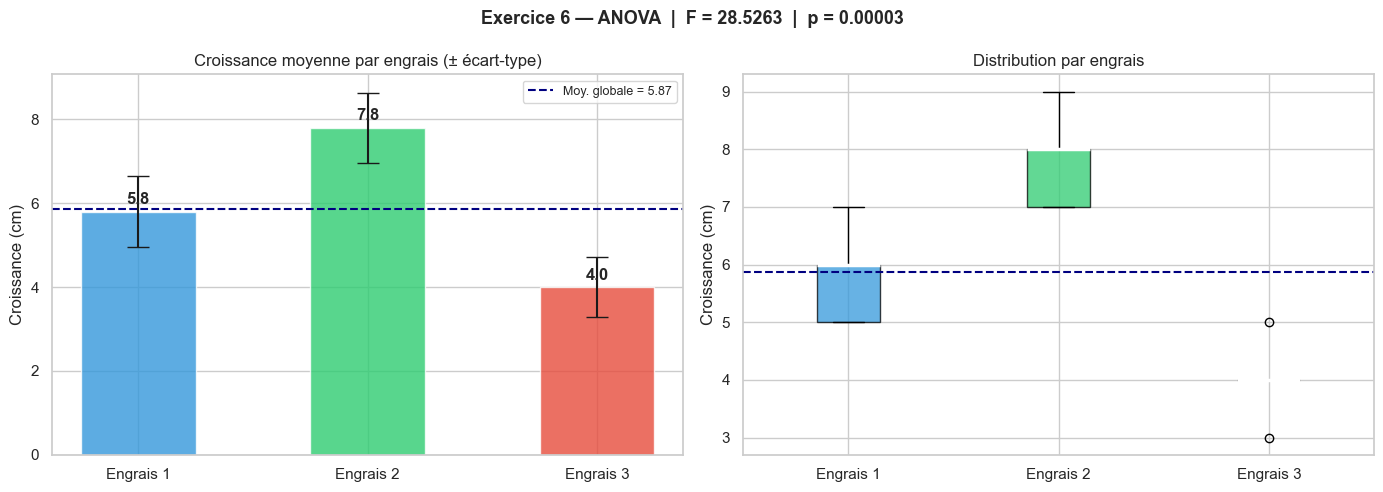

In [ ]:
from scipy.stats import f_oneway

fertilizer_1 = [5, 6, 7, 6, 5]
fertilizer_2 = [7, 8, 7, 9, 8]
fertilizer_3 = [4, 5, 4, 3, 4]

# ANOVA has a factor 
F_stat, p_value = f_oneway(fertilizer_1, fertilizer_2, fertilizer_3)
alpha = 0.05

print("ANOVA — Fertilizer efficiency")
print(f"  Fertilizer 1 : mean = {np.mean(fertilizer_1):.2f} cm,  data = {fertilizer_1}")
print(f"  Fertilizer 2 : mean = {np.mean(fertilizer_2):.2f} cm,  data = {fertilizer_2}")
print(f"  Fertilizer 3 : mean = {np.mean(fertilizer_3):.2f} cm,  data = {fertilizer_3}")
print()
print(f"  F-statistic : {F_stat:.4f}")
print(f"  P-Value      : {p_value:.6f}")
print(f"  Significance Level α       : {alpha}")
print()
if p_value < alpha:
    print(f" p = {p_value:.5f} < α = {alpha}")
    print("     We reject H₀: at least one fertilizer has a significantly different effect.")
else:
    print(f" p = {p_value:.5f} ≥ α = {alpha}")
    print("     We fail to reject H₀.")

print("\n Rappel des hypothèses :")
print("  H₀ : μ₁ = μ₂ = μ₃  (All fertilizers have the same effect)")
print("  H₁ : At least one mean is different")

print("\n If p > 0.05 :")
print("  We would not be able to conclude that the fertilizers have different effects.")
print("  The observed differences would be attributable to random variation.")

# ANOVA manual board 
all_data = fertilizer_1 + fertilizer_2 + fertilizer_3
grand_mean = np.mean(all_data)
groups = [fertilizer_1, fertilizer_2, fertilizer_3]
n_groups = len(groups)
n_total = len(all_data)

SSB = sum(len(g) * (np.mean(g) - grand_mean)**2 for g in groups)
SSW = sum(sum((x - np.mean(g))**2 for x in g) for g in groups)
dfB = n_groups - 1
dfW = n_total - n_groups
MSB = SSB / dfB
MSW = SSW / dfW

print(f"\n ANOVA Board :")
print(f"  {'Source':<20} {'SC':>10} {'dl':>5} {'CM':>10} {'F':>8}")
print("  " + "-" * 55)
print(f"  {'Inter-groupes':<20} {SSB:>10.3f} {dfB:>5} {MSB:>10.3f} {F_stat:>8.4f}")
print(f"  {'Intra-groupes':<20} {SSW:>10.3f} {dfW:>5} {MSW:>10.3f}")
print(f"  {'Total':<20} {SSB+SSW:>10.3f} {dfB+dfW:>5}")

# Visualisation 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"Exercice 6 — ANOVA  |  F = {F_stat:.4f}  |  p = {p_value:.5f}",
             fontsize=13, fontweight='bold')

# Graphic 1 : error bars
means = [np.mean(g) for g in groups]
stds  = [np.std(g, ddof=1) for g in groups]
colors = ['#3498db', '#2ecc71', '#e74c3c']
labels = ['Engrais 1', 'Engrais 2', 'Engrais 3']
ax = axes[0]
bars = ax.bar(labels, means, yerr=stds, color=colors, alpha=0.8,
              capsize=8, edgecolor='white', width=0.5)
ax.axhline(grand_mean, color='navy', linestyle='--', linewidth=1.5, label=f'Mean = {grand_mean:.2f}')
ax.set_title('Average Growth by Fertilizer (± Standard Deviation)')
ax.set_ylabel('Growth (cm)')
ax.legend(fontsize=9)
for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, mean + 0.1, f'{mean:.1f}',
            ha='center', va='bottom', fontweight='bold')

# Graphic 2 : boxes of whiskers
bp = axes[1].boxplot(groups, patch_artist=True,
                     labels=labels,
                     medianprops=dict(color='white', linewidth=2.5))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
axes[1].axhline(grand_mean, color='navy', linestyle='--', linewidth=1.5)
axes[1].set_title('Distribution by Fertilizer')
axes[1].set_ylabel('Growth (cm)')

plt.tight_layout()
plt.show()


## Exercice 7

 Binomial Distribution  B(n=10, p=0.5)
  P(X = 5) = 0.2461  (24.61%)

  k     P(X=k)       P(X≤k) CDF     Interpretation
  ------------------------------------------------------------
  0     0.0010       0.0010        
  1     0.0098       0.0107        
  2     0.0439       0.0547        
  3     0.1172       0.1719        
  4     0.2051       0.3770        
  5     0.2461       0.6230         ◀ k=5
  6     0.2051       0.8281        
  7     0.1172       0.9453        
  8     0.0439       0.9893        
  9     0.0098       0.9990        
  10    0.0010       1.0000        

  P(X ≤ 5)  = 0.6230
  P(X ≥ 5)  = 0.6230
  P(X ≥ 8)  = 0.0547  (obtain 8, 9 or 10 faces)
  Expectation = n×p = 5.0 faces
  Variance  = n×p×(1-p) = 2.50


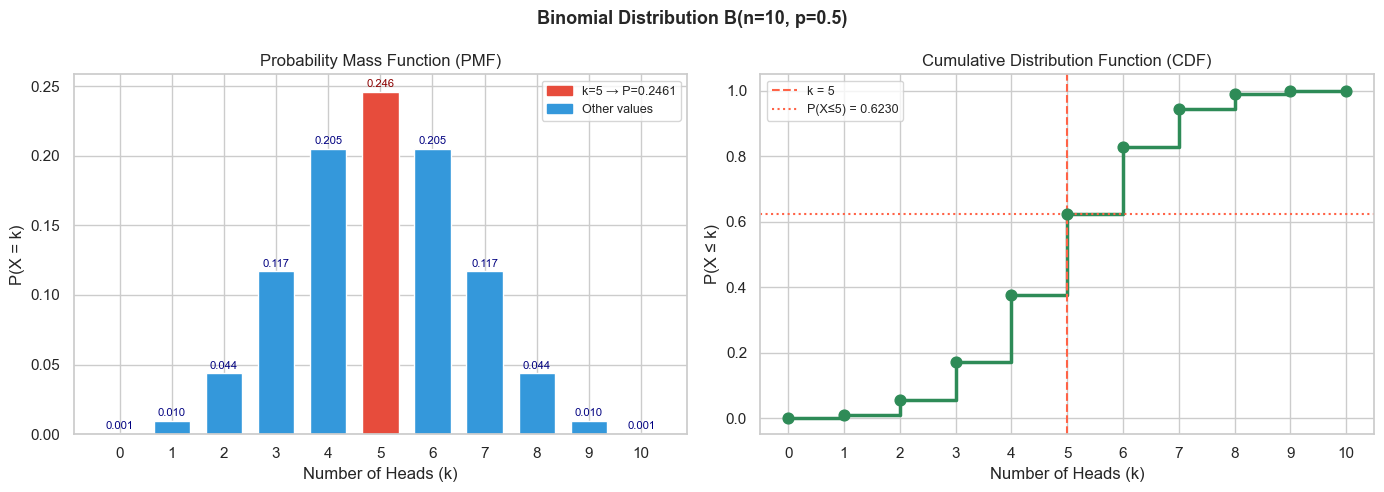

In [18]:
from scipy.stats import binom

n = 10    
p = 0.5   

# Probability of exactly 5 faces
k = 5
prob_exacte = binom.pmf(k, n, p)
print(f" Binomial Distribution  B(n={n}, p={p})")
print("=" * 50)
print(f"  P(X = {k}) = {prob_exacte:.4f}  ({prob_exacte*100:.2f}%)")
print()

# Table of probabilities for k = 0 to 10
print(f"  {'k':<5} {'P(X=k)':<12} {'P(X≤k) CDF':<14} Interpretation")
print("  " + "-" * 60)
for ki in range(n + 1):
    pmf = binom.pmf(ki, n, p)
    cdf = binom.cdf(ki, n, p)
    marker = " ◀ k=5" if ki == k else ""
    print(f"  {ki:<5} {pmf:<12.4f} {cdf:<14.4f}{marker}")

# Probabilities
print(f"\n  P(X ≤ 5)  = {binom.cdf(5, n, p):.4f}")
print(f"  P(X ≥ 5)  = {1 - binom.cdf(4, n, p):.4f}")
print(f"  P(X ≥ 8)  = {1 - binom.cdf(7, n, p):.4f}  (obtain 8, 9 or 10 faces)")
print(f"  Expectation = n×p = {n*p:.1f} faces")
print(f"  Variance  = n×p×(1-p) = {n*p*(1-p):.2f}")

# Visualisation 
k_vals = np.arange(0, n + 1)
pmf_vals = binom.pmf(k_vals, n, p)
cdf_vals = binom.cdf(k_vals, n, p)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"Binomial Distribution B(n={n}, p={p})",
             fontsize=13, fontweight='bold')

# PMF
bar_colors = ['#e74c3c' if ki == k else '#3498db' for ki in k_vals]
bars = axes[0].bar(k_vals, pmf_vals, color=bar_colors, edgecolor='white', width=0.7)
axes[0].set_title('Probability Mass Function (PMF)')
axes[0].set_xlabel('Number of Heads (k)')
axes[0].set_ylabel('P(X = k)')
axes[0].set_xticks(k_vals)
for ki, pmf in zip(k_vals, pmf_vals):
    axes[0].text(ki, pmf + 0.003, f'{pmf:.3f}', ha='center', fontsize=8,
                 color='darkred' if ki == k else 'navy')
# Legend
red_patch  = mpatches.Patch(color='#e74c3c', label=f'k=5 → P={prob_exacte:.4f}')
blue_patch = mpatches.Patch(color='#3498db', label='Other values')
axes[0].legend(handles=[red_patch, blue_patch], fontsize=9)

# CDF
axes[1].step(k_vals, cdf_vals, where='post', color='seagreen', linewidth=2.5)
axes[1].scatter(k_vals, cdf_vals, color='seagreen', s=60, zorder=5)
axes[1].axvline(k, color='tomato', linestyle='--', linewidth=1.5, label=f'k = {k}')
axes[1].axhline(binom.cdf(k, n, p), color='tomato', linestyle=':', linewidth=1.5,
                label=f'P(X≤{k}) = {binom.cdf(k,n,p):.4f}')
axes[1].set_title('Cumulative Distribution Function (CDF)')
axes[1].set_xlabel('Number of Heads (k)')
axes[1].set_ylabel('P(X ≤ k)')
axes[1].set_xticks(k_vals)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()
